In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [38]:
DATA_PATH = Path("WA_Fn-UseC_-HR-Employee-Attrition.csv")
assert DATA_PATH.exists(), f"Fichier introuvable: {DATA_PATH.resolve()}"

In [39]:
df = pd.read_csv(DATA_PATH)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [40]:
print("Shape:", df.shape)
display(df.columns.to_frame(index=False).rename(columns={0: "column"}))

Shape: (1470, 35)


,column
0,Age
1,Attrition
2,BusinessTravel
3,DailyRate
4,Department
5,DistanceFromHome
6,Education
7,EducationField
8,EmployeeCount
9,EmployeeNumber


In [41]:
df.dtypes.sort_values()

Age                          int64
YearsInCurrentRole           int64
YearsAtCompany               int64
WorkLifeBalance              int64
TrainingTimesLastYear        int64
TotalWorkingYears            int64
StockOptionLevel             int64
StandardHours                int64
RelationshipSatisfaction     int64
PerformanceRating            int64
PercentSalaryHike            int64
NumCompaniesWorked           int64
MonthlyRate                  int64
MonthlyIncome                int64
YearsSinceLastPromotion      int64
JobSatisfaction              int64
YearsWithCurrManager         int64
JobLevel                     int64
DailyRate                    int64
DistanceFromHome             int64
Education                    int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
EmployeeCount                int64
HourlyRate                   int64
JobInvolvement               int64
Over18                      object
JobRole                     object
EducationField      

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [43]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [44]:
print("Duplicats (lignes) :", df.duplicated().sum())

Duplicats (lignes) : 0


In [45]:
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique == 1].index.tolist()
constant_cols

['EmployeeCount', 'Over18', 'StandardHours']

In [46]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [47]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

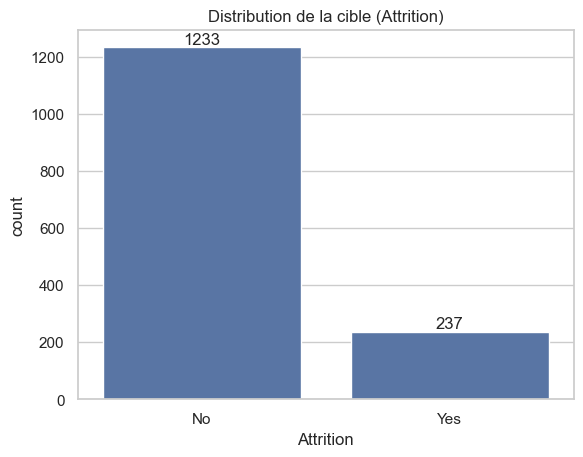

In [48]:
ax = sns.countplot(data=df, x="Attrition", order=["No", "Yes"])
ax.set_title("Distribution de la cible (Attrition)")
ax.bar_label(ax.containers[0])
plt.show()

In [49]:
# Baseline: toujours prédire la classe majoritaire
baseline_acc = df["Attrition"].value_counts(normalize=True).max()
print(f"Baseline accuracy (classe majoritaire) = {baseline_acc:.3f}")

Baseline accuracy (classe majoritaire) = 0.839


In [50]:
target_col = "Attrition"

cat_cols = df.select_dtypes(include=["object"]).columns.drop(target_col).tolist()
num_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", len(cat_cols))
print("Numeric:", len(num_cols))

Categorical: 8
Numeric: 26


In [51]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


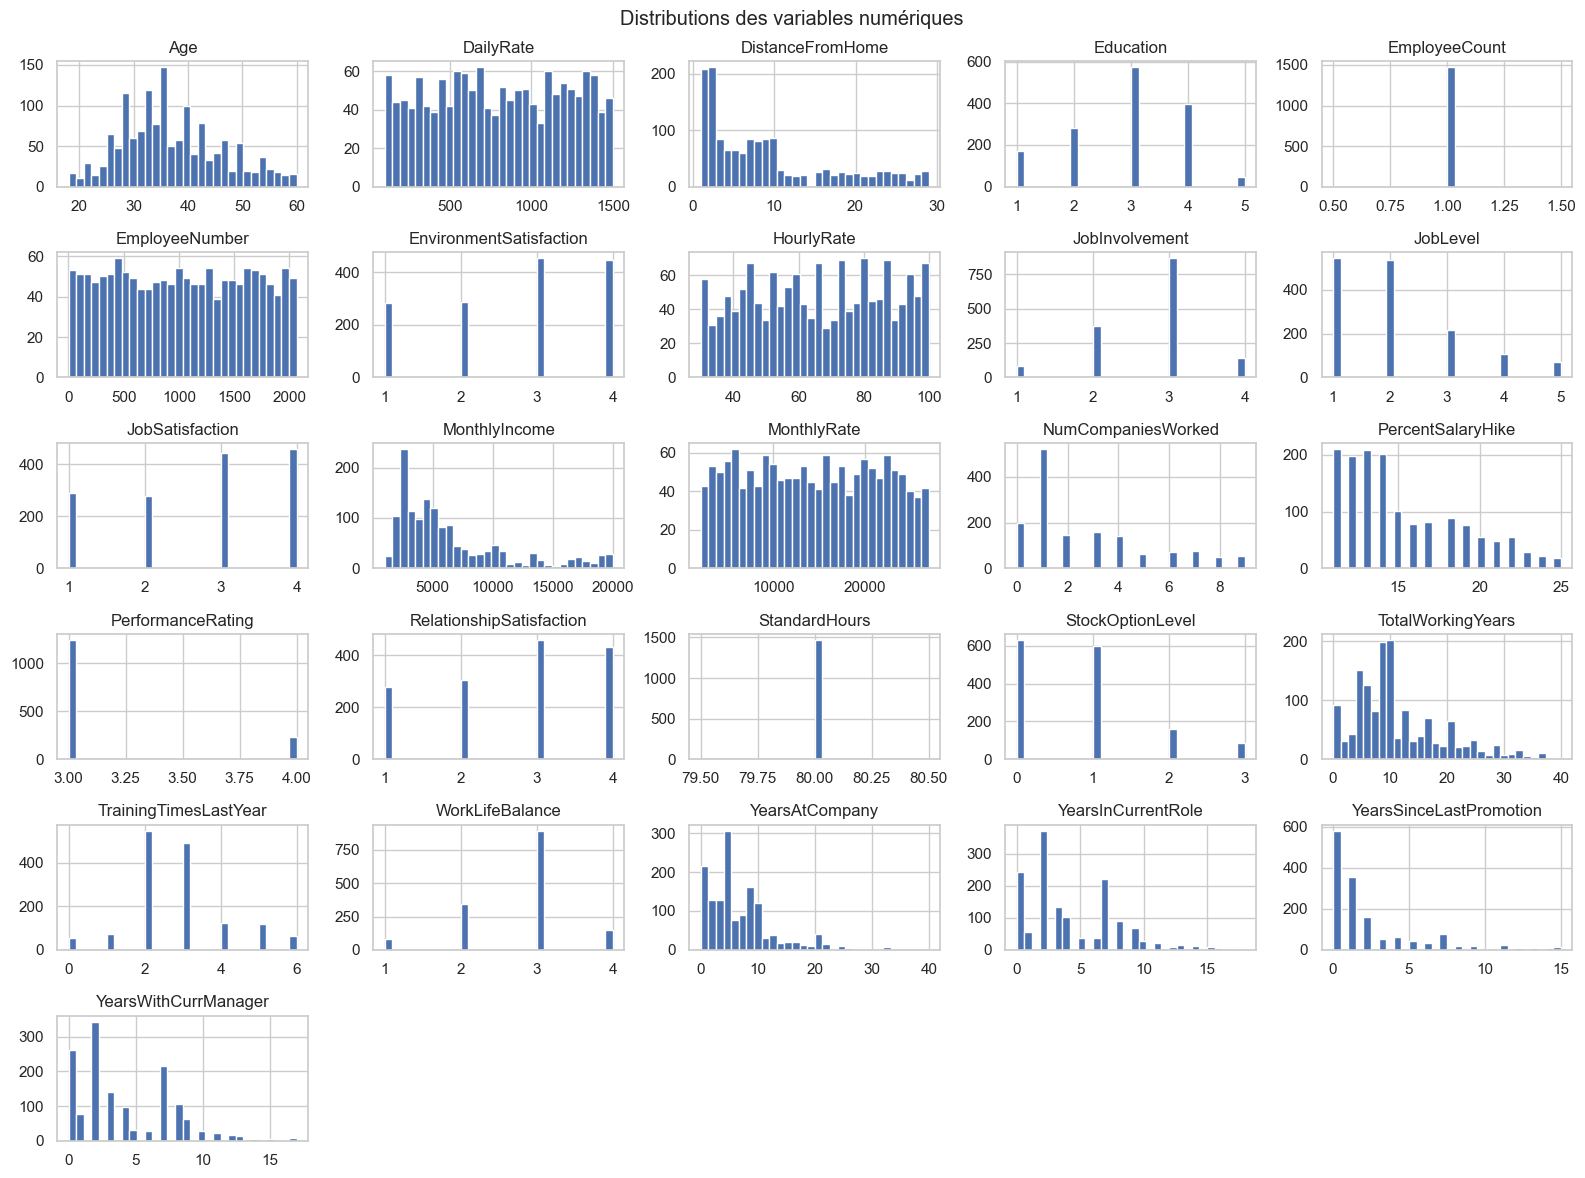

In [52]:
# Histos rapides (attention: peut être long selon nb colonnes)
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions des variables numériques")
plt.tight_layout()
plt.show()

In [53]:
# Aperçu des modalités pour quelques colonnes (top)
for c in cat_cols[:10]:
    print(f"\n{c}")
    display(df[c].value_counts().head(10))


BusinessTravel


BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


Department


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


EducationField


EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


Gender


Gender
Male      882
Female    588
Name: count, dtype: int64


JobRole


JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


MaritalStatus


MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


Over18


Over18
Y    1470
Name: count, dtype: int64


OverTime


OverTime
No     1054
Yes     416
Name: count, dtype: int64

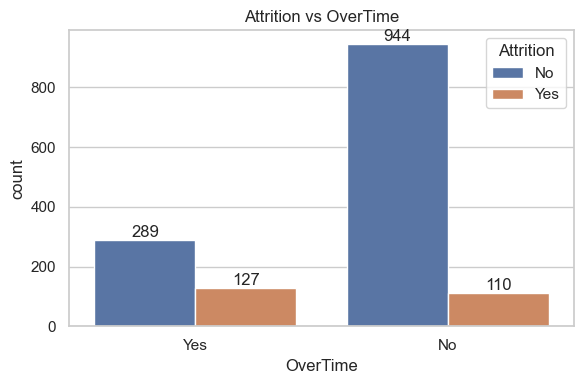

In [54]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="OverTime", hue="Attrition", hue_order=["No", "Yes"])
ax.set_title("Attrition vs OverTime")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.tight_layout()
plt.show()

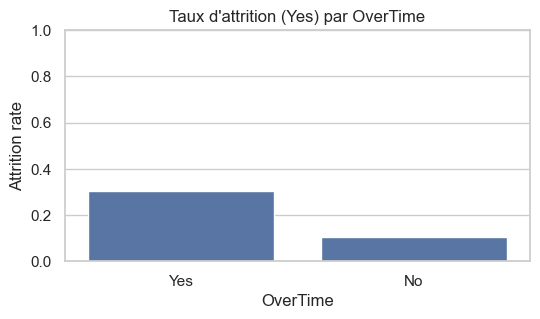

OverTime
Yes    0.305288
No     0.104364
Name: Attrition, dtype: float64

In [55]:
rate = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda s: (s == "Yes").mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,3))
sns.barplot(x=rate.index, y=rate.values)
plt.title("Taux d'attrition (Yes) par OverTime")
plt.ylabel("Attrition rate")
plt.ylim(0, 1)
plt.show()

rate

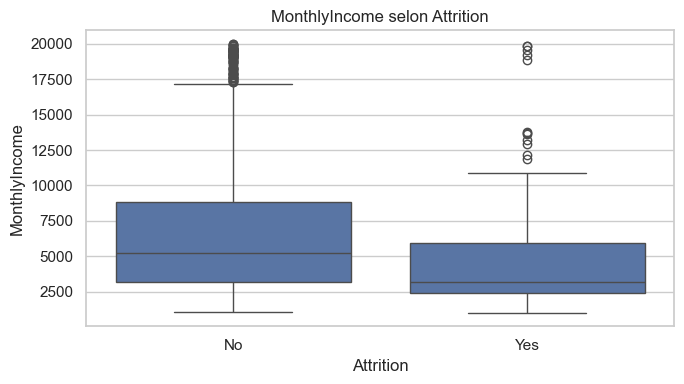

In [56]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["No", "Yes"])
plt.title("MonthlyIncome selon Attrition")
plt.tight_layout()
plt.show()

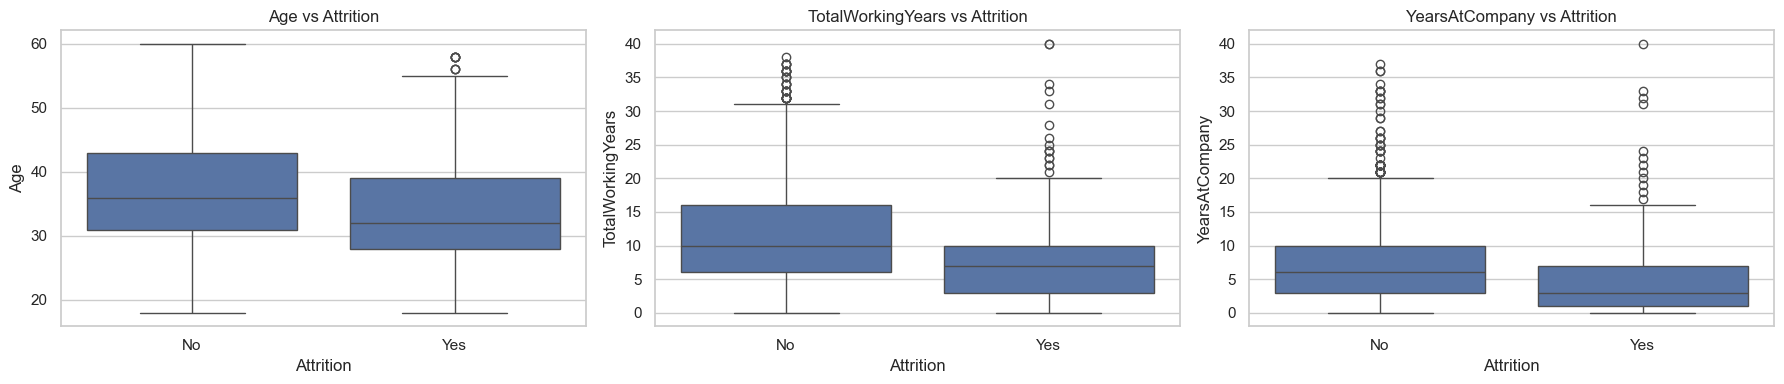

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(data=df, x="Attrition", y="Age", order=["No", "Yes"], ax=axes[0])
axes[0].set_title("Age vs Attrition")

sns.boxplot(data=df, x="Attrition", y="TotalWorkingYears", order=["No", "Yes"], ax=axes[1])
axes[1].set_title("TotalWorkingYears vs Attrition")

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany", order=["No", "Yes"], ax=axes[2])
axes[2].set_title("YearsAtCompany vs Attrition")

plt.tight_layout()
plt.show()

In [58]:
drop_cols = []
# constantes
drop_cols += constant_cols

# IDs ou colonnes généralement non prédictives (à valider selon ton cours/projet)
for c in ["EmployeeNumber"]:
    if c in df.columns:
        drop_cols.append(c)

drop_cols = sorted(set(drop_cols))
drop_cols

['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

In [59]:
df_clean = df.drop(columns=drop_cols)
print("Avant:", df.shape)
print("Après:", df_clean.shape)
df_clean.head()

Avant: (1470, 35)
Après: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [60]:
df_clean["AttritionFlag"] = (df_clean["Attrition"] == "Yes").astype(int)
df_clean[["Attrition", "AttritionFlag"]].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


Confusion matrix:
 [[191  56]
 [ 17  30]]

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

ROC-AUC: 0.8031699543457662


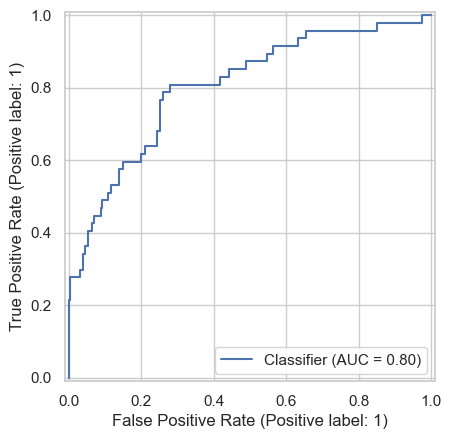

In [61]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# 1) Cible
y = df_clean["AttritionFlag"]

# 2) Features: on enlève Attrition et la target
X = df_clean.drop(columns=["Attrition", "AttritionFlag"])

# (Optionnel mais souvent utile)
# X = X.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours"], errors="ignore")

# 3) Séparer colonnes
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

# 4) Préprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# 5) Modèle
model = LogisticRegression(max_iter=2000, class_weight="balanced")  # balanced utile si dataset déséquilibré

# 6) Pipeline
clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", model)
])

# 7) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8) Train
clf.fit(X_train, y_train)

# 9) Prédiction
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

In [64]:
# 1) Préparation
target_col = "Attrition"

# Colonnes à enlever (constantes)
drop_cols = ["EmployeeCount", "Over18", "StandardHours"]

df_model = df.drop(columns=drop_cols).copy()

# y = cible en 0/1
y = df_model[target_col].map({"No": 0, "Yes": 1})

# X = variables (sans la cible)
X = df_model.drop(columns=[target_col])

# Transformer les colonnes "texte" en colonnes numériques (0/1) automatiquement
X = pd.get_dummies(X, drop_first=True)

X.shape, y.value_counts()

((1470, 45),
 Attrition
 0    1233
 1     237
 Name: count, dtype: int64)

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((1176, 45), (294, 45))

In [66]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=4
)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = tree.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred, target_names=["No", "Yes"]))

Accuracy: 0.81

Confusion matrix:
 [[232  15]
 [ 41   6]]

Report:
               precision    recall  f1-score   support

          No       0.85      0.94      0.89       247
         Yes       0.29      0.13      0.18        47

    accuracy                           0.81       294
   macro avg       0.57      0.53      0.53       294
weighted avg       0.76      0.81      0.78       294



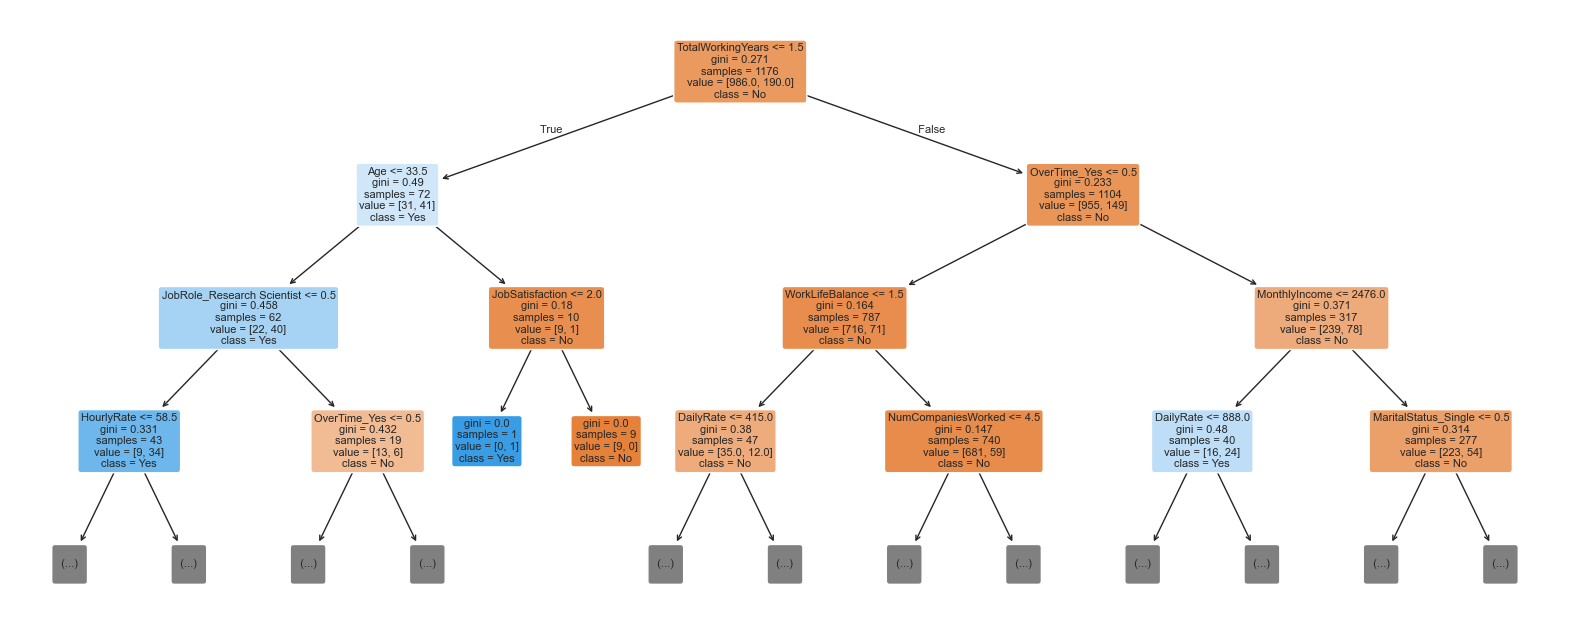

In [68]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,  # pour afficher seulement le haut de l'arbre
    fontsize=8
)
plt.show()

In [69]:
tree_balanced = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=4,
    class_weight="balanced"
)

tree_balanced.fit(X_train, y_train)
y_pred_bal = tree_balanced.predict(X_test)

print("Accuracy (balanced):", round(accuracy_score(y_test, y_pred_bal), 3))
print("\nConfusion matrix (balanced):\n", confusion_matrix(y_test, y_pred_bal))
print("\nReport (balanced):\n", classification_report(y_test, y_pred_bal, target_names=["No", "Yes"]))

Accuracy (balanced): 0.721

Confusion matrix (balanced):
 [[189  58]
 [ 24  23]]

Report (balanced):
               precision    recall  f1-score   support

          No       0.89      0.77      0.82       247
         Yes       0.28      0.49      0.36        47

    accuracy                           0.72       294
   macro avg       0.59      0.63      0.59       294
weighted avg       0.79      0.72      0.75       294



In [70]:
# --- Data Preparation pour le modèle (simple) ---

# 1) On enlève les colonnes constantes trouvées
df_clean = df.drop(columns=constant_cols).copy()

# (Optionnel mais conseillé) enlever un identifiant
df_clean = df_clean.drop(columns=["EmployeeNumber"], errors="ignore")

# 2) Créer la cible en 0/1
df_clean["AttritionFlag"] = (df_clean["Attrition"] == "Yes").astype(int)

# 3) X = variables, y = cible
y = df_clean["AttritionFlag"]
X = df_clean.drop(columns=["Attrition", "AttritionFlag"])

# 4) Transformer les colonnes texte en colonnes numériques automatiquement
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (1470, 44)
y distribution:
 AttritionFlag
0    1233
1     237
Name: count, dtype: int64


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((1176, 44), (294, 44))

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=4,
    class_weight="balanced"   # aide à mieux détecter les "Yes"
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred, target_names=["No", "Yes"]))

Accuracy: 0.718

Confusion matrix:
 [[188  59]
 [ 24  23]]

Report:
               precision    recall  f1-score   support

          No       0.89      0.76      0.82       247
         Yes       0.28      0.49      0.36        47

    accuracy                           0.72       294
   macro avg       0.58      0.63      0.59       294
weighted avg       0.79      0.72      0.75       294



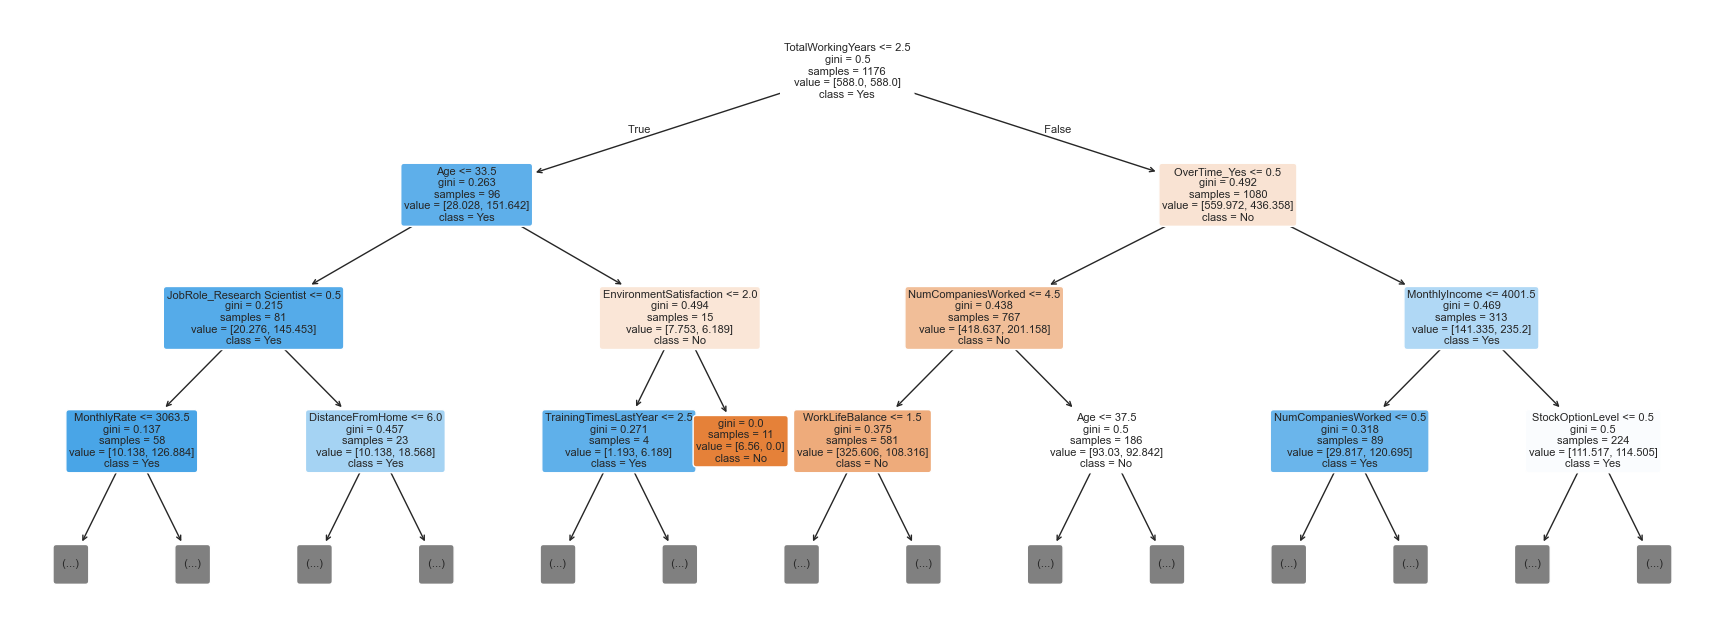

In [74]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.show()